<a href="https://colab.research.google.com/github/josef0731/AIxBio_Workshops/blob/main/workshop07-protein-design/protein_design_workshop_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Protein Design Workshop 2026 - Part 2
Dongjun Guo @ Ctrl-Alt-Bio 2026, UCL
<br/>


## Design of Mini-Protein Inhibitors Against SARS-CoV-2 Spike Protein
### Implemented with BoltzGen

This notebook re-implements the protein design pipeline using **BoltzGen**.

💻 [GitHub](https://github.com/HannesStark/boltzgen) | 📄 [BoltzGen paper](https://www.biorxiv.org/content/10.1101/2025.11.20.689494v1)


| | RFDiffusion pipeline | BoltzGen |
|---|---|---|
| **Backbone Generation** | RFDiffusion | BoltzGen |
| **Inverse Folding** | ProteinMPNN | BoltzIF |
| **Refolding** | AlphaFold3 | Boltz-2 |

<br/>

**Goal:** Design three-helix bundle (3HB) mini-proteins that mimic the ACE2 binding interface and block SARS-CoV-2 RBD entry.


---
⚠️ **Before you start:** Go to *Runtime → Change runtime type → T4 GPU*

## Table of Contents
1. [Environment Setup](#setup)
2. [GPU Check](#gpu)
3. [Fetch & Prepare Target Structure (PDB 8WE1)](#target)
4. [Define the Design Specification (ACE2 Binding Motif + 3HB)](#yaml)
5. [Run the BoltzGen Pipeline](#run)
6. [Inspect Results & Visualise Designs](#results)
7. [Assess Design Quality](#assess)
8. [Download Results](#download)

## 1. Environment Setup <a id='setup'></a>

In [ ]:
# @title Dependencies setup
# Install BoltzGen and visualisation dependencies
!pip install boltzgen py3Dmol biopython -q

# Verify installation
!boltzgen --version


import os, subprocess, yaml, urllib.request, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import py3Dmol

OUTPUT_DIR = Path('boltzgen_output')
CACHE_DIR  = Path('boltzgen_cache')
for d in [OUTPUT_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

#print(f"Output : {OUTPUT_DIR.resolve()}")
#print(f"Cache  : {CACHE_DIR.resolve()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.1/357.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.2/183.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2

## 2. GPU Check <a id='gpu'></a>

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM)")
else:
    raise SystemExit("❌ No GPU detected. Go to Runtime → Change runtime type → T4 GPU.")

✅ GPU: Tesla T4  (15.6 GB VRAM)


## 3. Fetch & Prepare Target Structure (PDB 8WE1) <a id='target'></a>

We use **PDB 8WE1** — *SARS-CoV-2 Omicron BF.7 RBD complexed with human ACE2* — as the design template.

- **Chain A** — Human ACE2 (residues 19–83 = binding motif: helices H1 and H2)
- **Chain B** — SARS-CoV-2 RBD (the target we want to block)

In [ ]:
# @markdown This cell will:
# @markdown - Download the PDB structure
# @markdown - Check chains included in the structure
# @markdown - Visualize the structure

# @markdown You will see the **ACE2 binding motif (H1+H2, residues 19–83)** (Green), **SARS-CoV-2 RBD** (Purple), and hotspot residues to preserve (yellow sticks)


PDB_ID = "8WE1"

CIF_PATH = Path(f'{PDB_ID.lower()}.cif')


if not CIF_PATH.exists():
    url = f'https://files.rcsb.org/download/{PDB_ID.lower()}.cif'
    print(f'Downloading {PDB_ID} from RCSB...')
    urllib.request.urlretrieve(url, CIF_PATH)
    print(f'Saved to {CIF_PATH}')
else:
    print(f'Already downloaded: {CIF_PATH}')

# Quick sanity check — count chains
chains = set()
with open(CIF_PATH) as f:
    for line in f:
        if line.startswith('ATOM') or line.startswith('HETATM'):
            parts = line.split()
            if len(parts) > 6:
                chains.add(parts[6])
print(f'Chains found in {PDB_ID}: {sorted(chains)}')


# Visualise the ACE2–RBD complex
# Chain A (ACE2) = blue | Chain B (RBD) = purple | ACE2 binding motif (A19-83) = green
with open(CIF_PATH) as fh:
    cif_data = fh.read()

view = py3Dmol.view(width=820, height=500)
view.addModel(cif_data, 'cif')
view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'lightblue', 'opacity': 0.5}})
view.setStyle({'chain': 'B'}, {'cartoon': {'color': '#9b59b6',   'opacity': 0.8}})
# Highlight binding motif (H1+H2 helices, residues 19-83 on chain A)
view.setStyle({'chain': 'A', 'resi': list(range(19, 84))},
              {'cartoon': {'color': '#2ecc71', 'opacity': 1.0}})
# Hotspot residues as sticks
hotspot_resi = [24, 28, 31, 34, 38, 42, 79, 82, 83]
view.addStyle({'chain': 'A', 'resi': hotspot_resi}, {'stick': {'color': 'yellow'}})
view.setBackgroundColor('#1a1a2e')
view.zoomTo({'chain': 'A', 'resi': list(range(19, 84))})
view.show()


Saved to 8we1.cif
Chains found in 8WE1: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 4. Define the Design Specification (ACE2 Binding Motif + 3HB) <a id='yaml'></a>

The design strategy mimics the ACE2–RBD interaction:

1. **Fix** the ACE2 binding motif (residues 19–83, chain A) — this anchors helices H1 and H2
2. **Preserve hotspot residues** (A24, A28, A31, A34, A38, A42, A79, A82, A83) — key H-bonds and hydrophobic contacts
3. **Design a third helix** (30–35 aa) at the C-terminus of the motif to complete the 3HB topology
4. **Keep the RBD** (chain B) as the static target context



In [ ]:
# @title Set parameters to run boltzgen

# @markdown ### **Binder**
cif_path = CIF_PATH

# @markdown - include (which residues are included in the binder structure):
binder_chain_id    = "A"  # @param {type:"string", placeholder:"e.g. A"}
binder_included_res = "19..83"  # @param {type:"string", placeholder:"e.g. 19..83"}

# @markdown - design (which residues in the binder should be designed):

binder_design_chain_id = "A"  # @param {type:"string", placeholder:"e.g. A"}
binder_design_res      = "19..23,25..27,29..30,32..33,35..37,39..41,43..78,80..81"  # @param {type:"string", placeholder:"e.g. 1..41, 43..100"}

# @markdown &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *Note*: Here you only include residues you wish to be re-designed (i.e. You should exclude all the hotspots A24, A28, A31, A34, A38, A42, A79, A82, A83)

# @markdown &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; *Hint*: If you want to design all the residues except number 42 in a protein contains residue 1-100, you should write "1..41,43..100" here.


# @markdown - design_insertions (Use this when you want to specify the insertion of the fragments of the re-designed binder, which is our case)
insertion_chain_id = "A"  # @param {type:"string", placeholder:"e.g. A"}
insertion_start_point = 84 # @param {type:"integer", placeholder:"e.g. 84"}
insertion_number = "30..35" # @param {type:"string", placeholder:"e.g. 30..35"}
insertion_secondary_structure = "HELIX"  # @param ["HELIX", "SHEET", "LOOP", "UNSPECIFIED"]
# @markdown - binding types (where should the designed binder binds to?)
binding_chain_id = "B"  # @param {type:"string", placeholder:"e.g. B"}
binding_to = "all" # @param {type:"string", placeholder:"e.g. all"}




# @markdown ### **Target (fixed)**
target_chain_id = "B"  # @param {type:"string", placeholder:"e.g. B"}

# @markdown ### Output
output_yaml_path = "rbd_3hb_binder.yaml"  # @param {type:"string", placeholder:"e.g.rbd_3hb_binder.yaml"}


yaml_content = f"""\
entities:
  - file:
      path: {cif_path}
      include:
        - chain:
            id: {binder_chain_id}
            res_index: {binder_included_res}
      design:
        - chain:
            id: {binder_design_chain_id}
            res_index: {binder_design_res}
      design_insertions:
        - insertion:
            id: {insertion_chain_id}
            res_index: {insertion_start_point}
            num_residues: {insertion_number}
            secondary_structure: {insertion_secondary_structure}
      binding_types:
        - chain:
            id: {binding_chain_id}
            binding: {binding_to}
  - file:
      path: {cif_path}
      include:
        - chain:
            id: {target_chain_id}
  """

with open(output_yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Written to: {output_yaml_path}\n")
print(yaml_content)

Written to: rbd_3hb_binder.yaml

entities:
  - file:
      path: 8we1.cif
      include:
        - chain:
            id: A
            res_index: 19..83
      design:
        - chain:
            id: A
            res_index: 19..23,25..27,29..30,32..33,35..37,39..41,43..78,80..81
      design_insertions:
        - insertion:
            id: A
            res_index: 84
            num_residues: 30..35
            secondary_structure: HELIX
      binding_types:
        - chain:
            id: B
            binding: all
  - file:
      path: 8we1.cif
      include:
        - chain:
            id: B
  


#### Validate the spec before committing to the full run

In [ ]:

!boltzgen check {output_yaml_path}


mols.zip: 100% 391M/391M [00:03<00:00, 129MB/s]
Using dataset artifact: /root/.cache/huggingface/hub/datasets--boltzgen--inference-data/snapshots/c3d36fd276e9caf098c75d4113c6d5eb320b1a4c/mols.zip
************** Checking design spec: rbd_3hb_binder.yaml **************

Removing leading and/or trailing unresolved residues from included part of chain B in /content/8we1.cif.
  Leading unresolved:  ARG,VAL,GLN,PRO,THR,GLU,SER,ILE,VAL,ARG,PHE,PRO,ASN,ILE
  Trailing unresolved: LYS,LYS,SER,THR,ASN,LEU,VAL,LYS,ASN,LYS,CYS,VAL,ASN,PHE
[WARNING]: There were residues that have a structure group specified and are set to be designed. Make sure that you want to specify the backbone structure of designed residues.
Total designed residues: 89
Design specification visualization is written to rbd_3hb_binder.cif
***********************************************************************


## 5. Run the BoltzGen Pipeline <a id='run'></a>

BoltzGen executes these steps in sequence:

| BoltzGen step | |
|---|---|
| `design` | Protein scaffold generation |
| `inverse_folding` | Sequence design |
| `folding` | Refold the sequence generated into a 3D structure |
| `analysis` | Calculate metrices to evaluate designed binders |
| `filtering` | Filter the designed proteins using metrices calculated |


In [ ]:
import sys

# @markdown We need to include what is the protocol to run boltzgen, how many structures we want boltzgen to generate, and how many designs we want it to preserve after the filtering step.

# @markdown There are a number of different protocols (💻 [GitHub](https://github.com/HannesStark/boltzgen)) available in Boltzgen now. Here we use `protein-redesign` protocol.
PROTOCOL = "protein-redesign" # @param ["protein-redesign"]
NUM_DESIGNS = 4 # @param {"type":"integer", "placeholder":"Input a integer here"}
BUDGET = 1 #@param {"type":"integer", "placeholder":"Input a number here"}

cmd = [
    'boltzgen', 'run', str(output_yaml_path),
    '--output',       str(OUTPUT_DIR),
    '--protocol',     PROTOCOL,
    '--num_designs',  str(NUM_DESIGNS),
    '--budget',       str(BUDGET),
    '--cache',        str(CACHE_DIR),

]

print('Command running:', ' '.join(cmd))
print('─' * 70)

process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# Stream the output line by line
for line in process.stdout:
    print(line, end='')
    sys.stdout.flush() # Ensure the output is printed immediately

process.wait() # Wait for the process to complete

if process.returncode == 0:
    print('\n✅ BoltzGen pipeline complete!')
else:
    print('\n❌ Pipeline failed — check output above for details.')

Command running: boltzgen run rbd_3hb_binder.yaml --output boltzgen_output --protocol protein-redesign --num_designs 4 --budget 1 --cache boltzgen_cache
──────────────────────────────────────────────────────────────────────
2026-06-09 17:12:06.318294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Predicting: |          | 0/? [00:00<?, ?it/s]
[Step 1/5] design - Predicting: |          | 0/? [00:00<?, ?it/s]
[Step 1/5] design - Predicting: |          | 0/? [00:00<?, ?it/s]
[Step 1/5] design - Predicting DataLoader 0: :   0%|          | 0/4 [00:00<?,

## 6. Inspect Results & Visualise Designs <a id='results'></a>

*Below are taken from [boltzgen github](https://github.com/HannesStark/boltzgen/tree/main):*

When the pipeline completes your output directory will have:
- `config/`, `steps.yaml`: configuration files.
- `intermediate_designs/`: output of design step
  - `/*.cif` and `/*.npz`: CIF and NPZ (metadata files) for the designed proteins and targets before inverse folding
- `intermediate_designs_inverse_folded/`: output of inverse folding, folding, and analysis steps
  - `/*.cif` and `/*.npz` : CIF and NPZ for designed proteins and targets after inverse folding.  *Note: For designed residues, only the backbone atoms will have coordinates (sidechain coordinates will be 0,0,0).*
  - `/refold_cif`: refolded complex structures (target and binder). This is the primary input to the analysis and filtering steps.
  - `/refold_design_cif`: refolded binder structures, without target.
  - `/aggregate_metrics_analyze.csv`, `/per_target_metrics_analyze.csv` — outputs of the analysis step.
- `final_ranked_designs/` : outputs of the filtering step
  - `/intermediate_ranked_<N>_designs/` — top-N quality designs. CIFs are copied from `refold_cif` above.
  - `/final_<budget>_designs/` — quality + diversity set. CIFs copied from `refold_cif/`.
  - `/all_designs_metrics.csv` — metrics for all designs considered by filtering.
  - `/final_designs_metrics_<budget>.csv` — metrics for the selected final set.
  - `/results_overview.pdf` — plots

**We will inspect the `final_ranked_designs` in this workshop**

In [ ]:
#@title Visualise the top design: binder (chain A scaffold + new helix) bound to RBD
#@markdown You should see a third helix is generated after running boltzgen
final_struc_folder = OUTPUT_DIR / "final_ranked_designs/final_1_designs/"

struc_files = list(Path(final_struc_folder).glob('*.cif'))
DESIGN_NAME = struc_files[0].stem

if struc_files:
    top = struc_files[0]
    print(f'Visualising top design: {top.name}')
    fmt = 'cif' if top.suffix == '.cif' else 'pdb'

    view = py3Dmol.view(width=820, height=520)
    view.addModel(open(top).read(), fmt)
    view.setStyle({'chain': 'A'}, {'cartoon': {'color': 'red', 'opacity': 1.0}})
    view.setStyle({'chain': 'B'}, {'cartoon': {'color': '#9b59b6',   'opacity': 0.8}})
    # Highlight binding motif (H1+H2 helices, residues 19-83 on chain A)
    view.setStyle({'chain': 'A', 'resi': list(range(19, 84))},
              {'cartoon': {'color': '#2ecc71', 'opacity': 1.0}})
    # Hotspot residues as sticks
    hotspot_resi = [24, 28, 31, 34, 38, 42, 79, 82, 83]
    view.addStyle({'chain': 'A', 'resi': hotspot_resi}, {'stick': {'color': 'yellow'}})

    view.setBackgroundColor('#1a1a2e')
    view.zoomTo()
    view.show()
    print('Purple = RBD (target) | Red = The newly designed helix | Green = Two re-designed helix')
else:
    print('No structure files found.')

Visualising top design: rank1_rbd_3hb_binder_3.cif


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Purple = RBD (target) | Red = The newly designed helix | Green = Two re-designed helix


## 7. Assess Design Quality <a id='assess'></a>

Boltzgen automatically calculate different metrices to evaluate the design. It is written out under the output folder, in `final_ranked_designs/all_designs_metrics.csv`

In [ ]:
metrices=pd.read_csv(OUTPUT_DIR / "final_ranked_designs/all_designs_metrics.csv")
metrices

,id,final_rank,designed_sequence,designed_chain_sequence,num_design,design_to_target_iptm,min_design_to_target_pae,design_ptm,filter_rmsd,plip_hbonds_refolded,...,pass_GLU_fraction_filter,pass_LEU_fraction_filter,pass_VAL_fraction_filter,rank_design_residue_iptm,rank_iptm,rank_ptm,rank_neg_filter_rmsd_design,max_rank,secondary_rank,quality_score
0,rbd_3hb_binder_3,1,MSQAEGELLKAAELRLGELRDAGLAAALAPSAANLAAAAAAAALAL...,MSQAEQGELFLKKAAHELRDLGEQLRDAGLAAALAPSAANLAAAAA...,87,0.45975,5.80078,0.70084,1.97644,4,...,True,True,True,1.0,0.5,0.333333,0.75,1.0,1,1.000000
1,rbd_3hb_binder_0,2,VSEEEAEVHKLEEAKVIAAKDAAAAAKAAPSAAAAAAAIAAGAKAI...,VSEEEQAEVFHKKLEHEAKDVIAQAKDAAAAAKAAPSAAAAAAAIA...,86,0.39057,8.79790,0.81620,1.20628,3,...,True,True,True,2.0,1.0,0.666667,0.25,2.0,2,0.666667
2,rbd_3hb_binder_2,3,MSQAEGKLGLVAEGALGAAVAAGAAAIAFPTLAAAAAAAAAAAAAL...,MSQAEQGKLFGLKVAHEGADLGAQAVAAGAAAIAFPTLAAAAAAAA...,88,0.34930,9.68158,0.77294,1.48982,0,...,True,True,True,3.0,1.5,1.000000,0.50,3.0,3,0.333333
3,rbd_3hb_binder_1,4,MSEKEAELYKAEEGRILAAAAAAAAALAAPAAATAAAAAAAGAAGL...,MSEKEQAELFYKKAEHEGRDILAQAAAAAAAALAAPAAATAAAAAA...,88,0.13499,18.05970,0.34238,8.91273,1,...,True,True,True,4.0,2.0,1.333333,1.00,4.0,4,0.000000


In [ ]:
[i for i in list(metrices.columns) if "ptm" in i.lower()]

['design_to_target_iptm',
 'design_ptm',
 'ligand_iptm',
 'iptm',
 'ptm',
 'protein_iptm',
 'design_iptm',
 'design_iiptm',
 'design_residue_iptm',
 'target_ptm',
 'design_ptm>80',
 'design_ptm>75',
 'design_iptm>80',
 'design_iptm>70',
 'design_iptm>60',
 'design_iptm>50',
 'rank_design_residue_iptm',
 'rank_iptm',
 'rank_ptm']

In [ ]:
[i for i in list(metrices.columns) if "rmsd" in i.lower()]

['filter_rmsd',
 'native_rmsd',
 'native_rmsd_bb',
 'native_rmsd_refolded',
 'native_rmsd_bb_refolded',
 'bb_rmsd',
 'bb_rmsd_design',
 'bb_rmsd_target',
 'bb_rmsd_design_target',
 'bb_target_aligned_rmsd_design',
 'bb_rmsd<2.5',
 'bb_designability_rmsd_2',
 'bb_designability_rmsd_4',
 'filter_rmsd_design',
 'neg_filter_rmsd',
 'neg_filter_rmsd_design',
 'pass_filter_rmsd_filter',
 'pass_filter_rmsd_design_filter',
 'rank_neg_filter_rmsd_design']

In [ ]:
[i for i in list(metrices.columns) if "plddt" in i.lower()]

['complex_plddt', 'complex_iplddt']

Similarly to what we did in RFDiffusion, we can inspect RMSD, plddt, and iPTM of the designed binders.

<Axes: xlabel='final_rank', ylabel='filter_rmsd'>

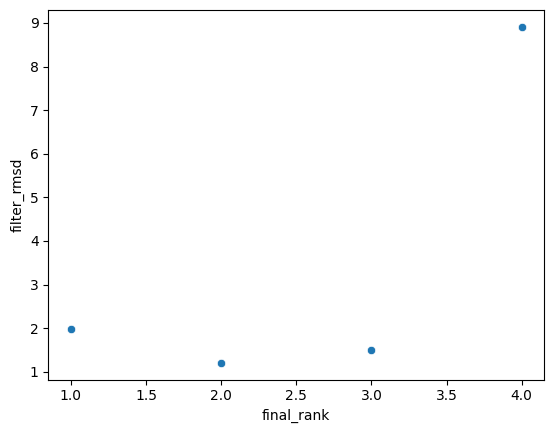

In [ ]:
import seaborn as sns
sns.scatterplot(metrices, x="final_rank", y="filter_rmsd")

<Axes: xlabel='final_rank', ylabel='complex_plddt'>

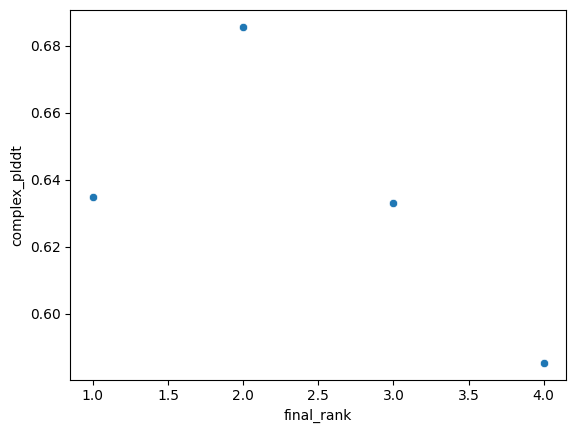

In [ ]:
sns.scatterplot(metrices, x="final_rank", y="complex_plddt")

<Axes: xlabel='final_rank', ylabel='iptm'>

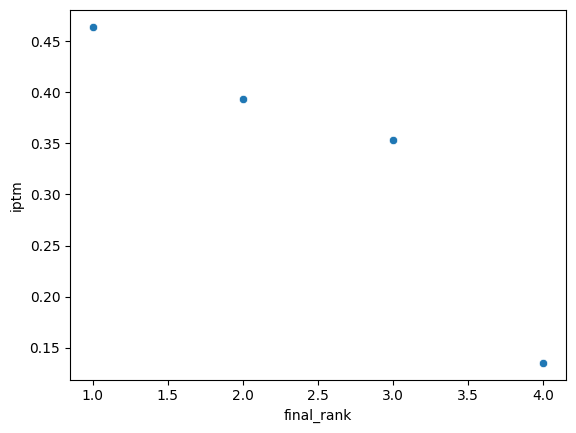

In [ ]:
sns.scatterplot(metrices, x="final_rank", y="iptm")

## 8. Download Results <a id='download'></a>

In [ ]:
archive = shutil.make_archive('boltzgen_3HB_rbd_binders', 'zip', OUTPUT_DIR)
print(f'Archive: {archive}')

try:
    from google.colab import files
    files.download(archive)
    print('Download started.')
except ImportError:
    print('Not in Colab — zip saved locally as boltzgen_3HB_rbd_binders.zip')

Archive: /content/boltzgen_3HB_rbd_binders.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
